# ETAS / thinning / FINE — classic + fast tracks

Copy of `compare_thinning_vs_thinning_magnet_ensemble.ipynb`, extended to compare:

| Series | Meaning |
|--------|---------|
| `etas` | Classic ETAS branching |
| `thinning` | Ogata thinning + GR magnitudes |
| `FINE_new` (default) | Ogata + MAGNET, FeatureState + GrowArray + sliding |
| `FINE_legacy` (opt-in) | Ogata + MAGNET, `FEATURE_STATE=0` (oracle `build_features`) |

## Data sources

1. **`fast_tracks`** (default) — capped fine-speed run under `outputs/etas_thinning_fine_fast_tracks/`
   (same inversion + MAGNET checkpoint; fair seed-matched comparison).
2. **`hauksson_classic`** — existing `outputs/hauksson_continuation_models`
   (`etas` / `thinning` / `thinning_magnet` only; no fast-track split).

Generate fast-track data (defaults: `etas,thinning,FINE_new`, 10 seeds, `--max-workers 6`, CPU `A_h`):

```bash
cd /home/neriberman/Repos/etas-fine-speed-gpu
export PYTHONPATH="$PWD:/home/neriberman/Repos/eq_mag_prediction/eq_mag_prediction_clean-ifs:${PYTHONPATH:-}"
/a/home/cc/students/csguests/neriberman/anaconda3/envs/etas_fine_speed_ifs/bin/python \
  runnable_code/run_etas_thinning_fine_fast_tracks.py --seed 0 --n-runs 10
# optional legacy compare:  ... --series etas,thinning,FINE_legacy,FINE_new
```


In [1]:
%matplotlib inline
from __future__ import annotations

import json
import math
import os
import re
import sys
from pathlib import Path
from typing import Literal

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from scipy import stats
from shapely.geometry import Polygon

# Ensure repo root and runnable_code are on sys.path for notebook imports
REPO_ROOT = Path.cwd().resolve()
if not (REPO_ROOT / "runnable_code" / "run_continuation_models.py").is_file():
    if REPO_ROOT.name == "notebooks":
        REPO_ROOT = REPO_ROOT.parent
    else:
        for parent in REPO_ROOT.parents:
            if (parent / "runnable_code" / "run_continuation_models.py").is_file():
                REPO_ROOT = parent
                break

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

if str(REPO_ROOT / "runnable_code") not in sys.path:
    sys.path.insert(0, str(REPO_ROOT / "runnable_code"))

for _candidate in [
    REPO_ROOT.parent / "eq_mag_prediction/eq_mag_prediction_clean",
    REPO_ROOT.parent / "eq_mag_prediction",
]:
    if (_candidate / "eq_mag_prediction").is_dir() and str(_candidate) not in sys.path:
        sys.path.insert(0, str(_candidate))
        break

import continuation_ensemble as ens
import etas.csep_utils as csep_utils
import etas.data_utils as data_utils
import etas.magnet_inference_cache as mic
import etas.utility_functions as uf

CONTINUATION_METHODS = ens.CONTINUATION_METHODS
MAGNET_METHOD = ens.METHOD_FINE_LEGACY
_FORECAST_CATALOG_NAME = ens._FORECAST_CATALOG_NAME
_REALIZATION_META_NAME = ens._REALIZATION_META_NAME
_MAGNET_PREDICTIONS_NAME = mic._DEFAULT_SIDECAR_NAME

METHOD_LABELS = ens.DEFAULT_METHOD_LABELS
METHOD_COLORS = ens.DEFAULT_METHOD_COLORS


def show_fig(fig=None):
    if fig is None:
        fig = plt.gcf()
    display(fig)
    plt.close(fig)


In [2]:
# ---------------------------------------------------------------------------
# User config — edit these
# ---------------------------------------------------------------------------

import benchmark_matrix_compare as bmc

DATA_SOURCE: Literal["fast_tracks", "hauksson_classic", "matrix", "standalone"] = "fast_tracks"

# --- fast_tracks mode (etas + thinning + FINE_legacy + FINE_new) ---
FAST_TRACKS_ROOT = REPO_ROOT / "outputs/etas_thinning_fine_fast_tracks"
# Logical series name → on-disk method folder under that series root
FAST_TRACK_SERIES: dict[str, tuple[str, Path]] = {
    # label: (folder_method_name_for_loader, series_root)
    "etas": ("etas", FAST_TRACKS_ROOT / "etas"),
    "thinning": ("thinning", FAST_TRACKS_ROOT / "thinning"),
    "FINE_legacy": ("FINE", FAST_TRACKS_ROOT / "FINE_legacy"),
    "FINE_new": ("FINE", FAST_TRACKS_ROOT / "FINE_new"),
}
# Default: new FINE only. Add "FINE_legacy" to compare oracle build_features.
METHODS: list[str] | None = ["etas", "thinning", "FINE_new"]

# --- hauksson_classic mode (original 3-way compare) ---
HAUKSSON_ROOT = REPO_ROOT / "outputs/hauksson_continuation_models"

# --- matrix / standalone (unchanged from original notebook) ---
RUN_ID = "benchmark_full_20260801"
CATALOG_ID = "hauksson"
VARIANT_ID = "mc_depth"
OUTPUT_ROOT = REPO_ROOT / "outputs/hauksson_magnet_sample_continuation_models"

INVERSION_ID: str | None = None
LOAD_MODE: Literal["all", "first_n", "seeds"] = "seeds"
FIRST_N: int = 5
SEEDS: list[int] = list(range(10))  # 10 realizations per method for stats

MAGNET_PRED_SEED: int | None = 0
SHOW_ACTUAL_CONTINUATION: bool = True
MAGNET_SCATTER_INTERACTIVE: bool = False
KUMA_EVENT_MODE: Literal["indices", "largest_m", "first_n", "magnitude_range"] = "largest_m"
KUMA_EVENT_INDICES: list[int] = []
KUMA_N_EVENTS: int = 6
KUMA_MAG_RANGE: tuple[float, float] | None = (6.0, 10.0)
KUMA_M_GRID: tuple[float, float, int] | None = None
MAGNET_PARAMS_EVENT_STRIDE: int = 1

# Distinct colors / labels for fast-track series (METHOD_LABELS extended below)
SERIES_LABELS = {
    "etas": "ETAS",
    "thinning": "thinning (GR)",
    "thinning_magnet": "FINE (legacy name)",
    "FINE": "FINE",
    "FINE_legacy": "FINE legacy (build_features)",
    "FINE_new": "FINE new (FeatureState+sliding)",
}
SERIES_COLORS = {
    "etas": "#4c78a8",
    "thinning": "#72b7b2",
    "thinning_magnet": "#f58518",
    "FINE": "#f58518",
    "FINE_legacy": "#e45756",
    "FINE_new": "#54a24b",
}


In [3]:
# Ensemble loading, rate statistics, and MAGNET Kumaraswamy utilities
# are imported from continuation_ensemble, etas.utility_functions, and etas.magnet_inference_cache.
list_inv_dirs = ens.list_inv_dirs
normalize_method_key = ens.normalize_method_key
method_folder_candidates = ens.method_folder_candidates
discover_methods = ens.discover_methods
discover_methods_from_roots = ens.discover_methods_from_roots
discover_realization_seeds = ens.discover_realization_seeds
select_seeds = ens.select_seeds
resolve_ensemble_dir = ens.resolve_ensemble_dir
pick_shared_inversion_id = ens.pick_shared_inversion_id
resolve_matrix_method_roots = ens.resolve_matrix_method_roots
realization_dir = ens.realization_dir
load_forecast_catalog = ens.load_forecast_catalog
load_realization_meta = ens.load_realization_meta
load_method_ensemble = ens.load_method_ensemble
load_intensity_context = ens.load_intensity_context
draw_cumulative_event_count = ens.draw_cumulative_event_count
draw_event_rate_by_bin = ens.draw_event_rate_by_bin

interevent_times = uf.interevent_times
median_interevent_days = uf.median_interevent_days
cumulative_on_grid = uf.cumulative_on_grid
events_per_time_bin = uf.events_per_time_bin
ylim_in_xrange = uf.ylim_in_xrange
add_test_window_inset = uf.add_test_window_inset

kumaraswamy_pdf = mic.kumaraswamy_pdf
mixture_pdf_normalized = mic.mixture_pdf_normalized
magnitude_pdf_from_prediction = mic.magnitude_pdf_from_prediction
parse_magnet_shift_stretch = mic.parse_magnet_shift_stretch
load_magnet_predictions = mic.load_magnet_predictions
select_kuma_event_indices = mic.select_kuma_event_indices
parse_kumaraswamy_params = mic.parse_kumaraswamy_params
plot_kumaraswamy_params_vs_time = mic.plot_kumaraswamy_params_vs_time


## Load ensembles


In [4]:
# Resolve method series → ensemble dirs (supports fast_tracks multi-root).
MATRIX_RUN_ROOT: Path | None = None
VARIANT_ROOT: Path | None = None
VARIANT_LABEL: str | None = None
method_roots: dict[str, Path]
loader_method: dict[str, str] = {}  # series label → folder method for resolve_ensemble_dir

if DATA_SOURCE == "fast_tracks":
    OUTPUT_ROOT = FAST_TRACKS_ROOT.resolve()
    SHARED_ROOT = (OUTPUT_ROOT / "shared").resolve()
    methods = list(METHODS) if METHODS is not None else list(FAST_TRACK_SERIES)
    method_roots = {}
    for label in methods:
        if label not in FAST_TRACK_SERIES:
            raise KeyError(f"Unknown fast-track series {label!r}; known={list(FAST_TRACK_SERIES)}")
        folder_method, root = FAST_TRACK_SERIES[label]
        root = root.resolve()
        if not root.is_dir():
            raise FileNotFoundError(
                f"Missing series root for {label}: {root}. "
                "Run runnable_code/run_etas_thinning_fine_fast_tracks.py first."
            )
        method_roots[label] = root
        loader_method[label] = folder_method
    # shared inversion lives under FAST_TRACKS_ROOT/shared
    inv_candidates = sorted((SHARED_ROOT / "inversions").glob("inv_*"))
    if not inv_candidates and INVERSION_ID is None:
        # fall back: discover from first series
        inv_id = None
    else:
        inv_id = INVERSION_ID or (inv_candidates[0].name.removeprefix("inv_") if inv_candidates else None)
elif DATA_SOURCE == "hauksson_classic":
    OUTPUT_ROOT = HAUKSSON_ROOT.resolve()
    SHARED_ROOT = OUTPUT_ROOT
    methods = ["etas", "thinning", "thinning_magnet"] if METHODS is None else [
        normalize_method_key(m) for m in METHODS
    ]
    method_roots = {m: OUTPUT_ROOT for m in methods}
    loader_method = {m: m for m in methods}
    inv_id = pick_shared_inversion_id(OUTPUT_ROOT, methods, INVERSION_ID, method_roots=method_roots)
elif DATA_SOURCE == "matrix":
    valid_variants = {v["id"] for v in bmc.MAGNET_VARIANTS}
    if VARIANT_ID not in valid_variants:
        raise ValueError(f"VARIANT_ID={VARIANT_ID!r} not in {sorted(valid_variants)}.")
    MATRIX_RUN_ROOT = bmc.resolve_matrix_run_root(REPO_ROOT, run_id=RUN_ID)
    catalogs_available = bmc.discover_catalog_ids(MATRIX_RUN_ROOT)
    if CATALOG_ID not in catalogs_available:
        raise FileNotFoundError(f"Catalog {CATALOG_ID!r} not under {MATRIX_RUN_ROOT}.")
    SHARED_ROOT, VARIANT_ROOT, method_roots = resolve_matrix_method_roots(
        MATRIX_RUN_ROOT, CATALOG_ID, VARIANT_ID
    )
    OUTPUT_ROOT = SHARED_ROOT
    VARIANT_LABEL = next((v["label"] for v in bmc.MAGNET_VARIANTS if v["id"] == VARIANT_ID), VARIANT_ID)
    discovered = discover_methods_from_roots(method_roots)
    methods = discovered if METHODS is None else [normalize_method_key(m) for m in METHODS]
    loader_method = {m: m for m in methods}
    inv_id = pick_shared_inversion_id(OUTPUT_ROOT, methods, INVERSION_ID, method_roots=method_roots)
elif DATA_SOURCE == "standalone":
    OUTPUT_ROOT = Path(OUTPUT_ROOT).expanduser()
    OUTPUT_ROOT = OUTPUT_ROOT if OUTPUT_ROOT.is_absolute() else (REPO_ROOT / OUTPUT_ROOT).resolve()
    SHARED_ROOT = OUTPUT_ROOT
    discovered = discover_methods(OUTPUT_ROOT)
    methods = discovered if METHODS is None else [normalize_method_key(m) for m in METHODS]
    method_roots = {m: OUTPUT_ROOT for m in methods}
    loader_method = {m: m for m in methods}
    inv_id = pick_shared_inversion_id(OUTPUT_ROOT, methods, INVERSION_ID, method_roots=method_roots)
else:
    raise ValueError(f"DATA_SOURCE={DATA_SOURCE!r}")

if not methods:
    raise FileNotFoundError(f"No methods for DATA_SOURCE={DATA_SOURCE}")

# Resolve inversion id for fast_tracks from series folders if needed
if DATA_SOURCE == "fast_tracks":
    if inv_id is None:
        # pick first inv under first series
        first_label = methods[0]
        folder = loader_method[first_label]
        invs = list_inv_dirs(method_roots[first_label] / folder)
        if not invs:
            # FINE folder name
            for cand in ("FINE", "thinning_magnet", "etas", "thinning"):
                invs = list_inv_dirs(method_roots[first_label] / cand)
                if invs:
                    folder = cand
                    loader_method[first_label] = cand
                    break
        if not invs:
            raise FileNotFoundError(f"No inv_* under {method_roots[first_label]}")
        inv_id = invs[0].name.removeprefix("inv_")

ensemble_dirs = {
    label: resolve_ensemble_dir(method_roots[label], loader_method[label], inv_id)
    for label in methods
}

seed_sets = {m: set(discover_realization_seeds(d)) for m, d in ensemble_dirs.items()}
common_available = sorted(set.intersection(*seed_sets.values()))
if not common_available:
    raise ValueError(f"No common seeds across {methods}. Per-method: {[ (m, sorted(s)) for m,s in seed_sets.items() ]}")

selected_seeds = select_seeds(common_available, mode=LOAD_MODE, first_n=FIRST_N, seeds=SEEDS)

catalogs_by_method: dict[str, dict[int, pd.DataFrame]] = {}
metas_by_method: dict[str, dict] = {}
for method, ens_dir in ensemble_dirs.items():
    catalogs, seeds_loaded, meta = load_method_ensemble(ens_dir, mode="seeds", seeds=selected_seeds)
    catalogs_by_method[method] = catalogs
    metas_by_method[method] = meta

selected_seeds = sorted(set.intersection(*(set(c) for c in catalogs_by_method.values())))
if not selected_seeds:
    raise ValueError("No catalogs loaded for the intersection of selected seeds.")

primary_method = methods[0]
primary_meta = metas_by_method[primary_method]

# Extend METHOD_LABELS / colors used by later cells
METHOD_LABELS = {**METHOD_LABELS, **SERIES_LABELS}
METHOD_COLORS = {**globals().get("METHOD_COLORS", {}), **SERIES_COLORS}


# Prefer a FINE* series for MAGNET detail panels
_magnet_candidates = [m for m in methods if m in ("FINE", "thinning_magnet", "FINE_legacy", "FINE_new") or "FINE" in m]
MAGNET_METHOD = _magnet_candidates[0] if _magnet_candidates else "FINE"

display(Markdown(
    f"**DATA_SOURCE=`{DATA_SOURCE}`** · inv=`{inv_id}` · methods=`{methods}` · "
    f"seeds=`{selected_seeds}` ({len(selected_seeds)})"
))
for m, d in ensemble_dirs.items():
    display(Markdown(f"- `{m}` → `{d}` ({len(catalogs_by_method[m])} catalogs)"))


**DATA_SOURCE=`fast_tracks`** · inv=`a03d7b966a77d150` · methods=`['etas', 'thinning', 'FINE_legacy', 'FINE_new']` · seeds=`[0]` (1)

- `etas` → `/home/neriberman/Repos/etas-fine-speed-gpu/outputs/etas_thinning_fine_fast_tracks/etas/etas/inv_a03d7b966a77d150` (1 catalogs)

- `thinning` → `/home/neriberman/Repos/etas-fine-speed-gpu/outputs/etas_thinning_fine_fast_tracks/thinning/thinning/inv_a03d7b966a77d150` (1 catalogs)

- `FINE_legacy` → `/home/neriberman/Repos/etas-fine-speed-gpu/outputs/etas_thinning_fine_fast_tracks/FINE_legacy/FINE/inv_a03d7b966a77d150` (1 catalogs)

- `FINE_new` → `/home/neriberman/Repos/etas-fine-speed-gpu/outputs/etas_thinning_fine_fast_tracks/FINE_new/FINE/inv_a03d7b966a77d150` (1 catalogs)

## Per-realization metrics


**Per-realization metrics:**

,seed,etas_n_events,etas_max_magnitude,etas_median_iet_days,etas_background,etas_triggered,etas_bg_frac,thinning_n_events,thinning_max_magnitude,thinning_median_iet_days,...,FINE_legacy_median_iet_days,FINE_legacy_background,FINE_legacy_triggered,FINE_legacy_bg_frac,FINE_new_n_events,FINE_new_max_magnitude,FINE_new_median_iet_days,FINE_new_background,FINE_new_triggered,FINE_new_bg_frac
0,0,67.0,5.191548,2.561429,20.0,47.0,0.298507,52.0,5.484977,2.2921,...,2.531670e-08,1.0,495.0,0.002016,496.0,10.599998,1.522494e-08,1.0,495.0,0.002016


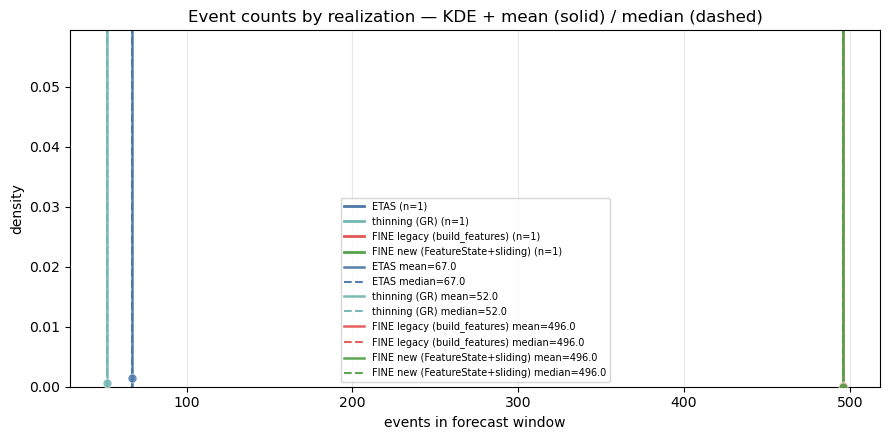

In [5]:
paired_metrics = pd.DataFrame({"seed": selected_seeds})

for method, catalogs in catalogs_by_method.items():
    for seed in selected_seeds:
        cat = catalogs[seed]
        row_mask = paired_metrics["seed"] == seed
        paired_metrics.loc[row_mask, f"{method}_n_events"] = len(cat)
        paired_metrics.loc[row_mask, f"{method}_max_magnitude"] = (
            float(cat["m"].max()) if len(cat) else np.nan
        )
        paired_metrics.loc[row_mask, f"{method}_median_iet_days"] = median_interevent_days(cat)
        if "event_source" in cat.columns:
            for sub in ("background", "triggered"):
                paired_metrics.loc[row_mask, f"{method}_{sub}"] = int(
                    (cat["event_source"] == sub).sum()
                )
            n = paired_metrics.loc[row_mask, f"{method}_n_events"].values[0]
            paired_metrics.loc[row_mask, f"{method}_bg_frac"] = (
                paired_metrics.loc[row_mask, f"{method}_background"].values[0] / n
                if n
                else np.nan
            )

display(Markdown("**Per-realization metrics:**"))
display(paired_metrics)

# Event-count distributions: points + hist/KDE + scalar vertical lines
_HIST_MIN_REALIZATIONS = 15
count_by_method = {
    method: paired_metrics[f"{method}_n_events"].to_numpy(dtype=float)
    for method in methods
}
all_counts = np.concatenate(list(count_by_method.values())) if count_by_method else np.array([])
if all_counts.size == 0:
    display(Markdown("_No event counts to plot._"))
else:
    x_lo = float(np.nanmin(all_counts))
    x_hi = float(np.nanmax(all_counts))
    x_pad = max(0.05 * (x_hi - x_lo), 1.0)
    x_lo, x_hi = x_lo - x_pad, x_hi + x_pad
    x_grid = np.linspace(x_lo, x_hi, 400)

    fig, ax = plt.subplots(figsize=(9, 4.5))
    rng_jitter = np.random.default_rng(0)
    use_hist = all(len(v) >= _HIST_MIN_REALIZATIONS for v in count_by_method.values())
    n_bins = max(8, min(30, int(np.sqrt(max(len(v) for v in count_by_method.values())))))

    for method in methods:
        counts = count_by_method[method]
        color = METHOD_COLORS[method]
        label = METHOD_LABELS[method]
        n = len(counts)
        if n == 0:
            continue
        if use_hist:
            ax.hist(
                counts,
                bins=n_bins,
                range=(x_lo, x_hi),
                density=True,
                alpha=0.35,
                color=color,
                label=f"{label} (n={n})",
            )
        elif n >= 2 and float(np.nanstd(counts)) > 0:
            kde = stats.gaussian_kde(counts)
            ax.plot(x_grid, kde(x_grid), color=color, lw=2.0, label=f"{label} KDE (n={n})")
        else:
            ax.plot([], [], color=color, lw=2.0, label=f"{label} (n={n})")

    # Realization points as a rug on the count axis
    ymax = max(ax.get_ylim()[1], 1e-6)
    rug_amp = 0.04 * ymax
    for method in methods:
        counts = count_by_method[method]
        if len(counts) == 0:
            continue
        color = METHOD_COLORS[method]
        y = rng_jitter.uniform(0.0, rug_amp, size=len(counts))
        ax.scatter(
            counts,
            y,
            color=color,
            s=42,
            alpha=0.85,
            zorder=5,
            edgecolors="white",
            linewidths=0.5,
        )
        mean_n = float(np.nanmean(counts))
        median_n = float(np.nanmedian(counts))
        ax.axvline(
            mean_n,
            color=color,
            ls="-",
            lw=1.8,
            alpha=0.95,
            label=f"{METHOD_LABELS[method]} mean={mean_n:.1f}",
        )
        ax.axvline(
            median_n,
            color=color,
            ls="--",
            lw=1.5,
            alpha=0.95,
            label=f"{METHOD_LABELS[method]} median={median_n:.1f}",
        )

    ax.set_xlim(x_lo, x_hi)
    ax.set_ylim(0.0, ymax * 1.08)
    ax.set_xlabel("events in forecast window")
    ax.set_ylabel("density")
    ax.set_title(
        f"Event counts by realization — "
        f"{'histogram' if use_hist else 'KDE'} + mean (solid) / median (dashed)"
    )
    ax.grid(True, alpha=0.3, axis="x")
    ax.legend(fontsize=7, loc="best")
    fig.tight_layout()
    show_fig(fig)


## Tier 1 — cumulative count and rate


_Could not load inversion context (name 'primary_dir' is not defined); using catalog times only._

/tmp/ipykernel_2449984/2426510309.py:89: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


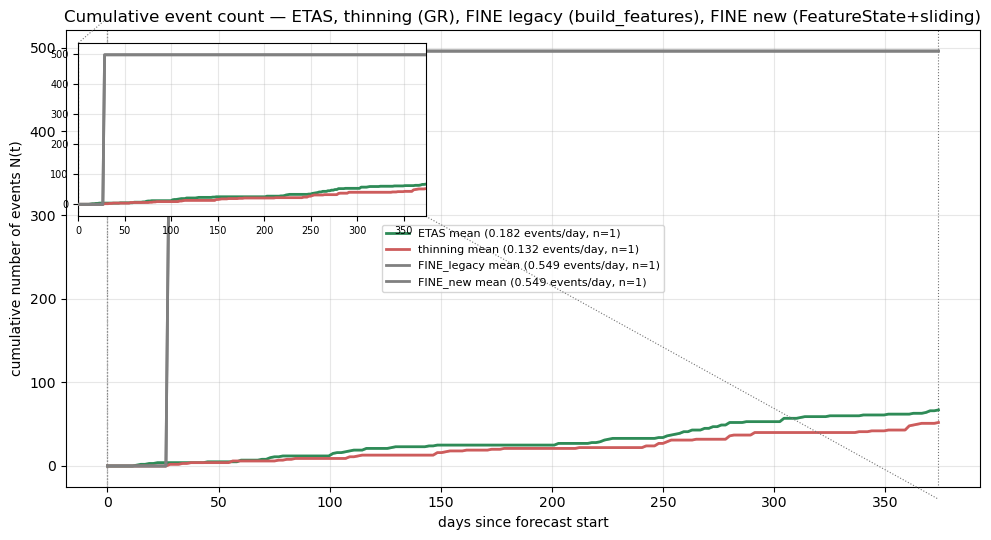

/tmp/ipykernel_2449984/2426510309.py:150: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


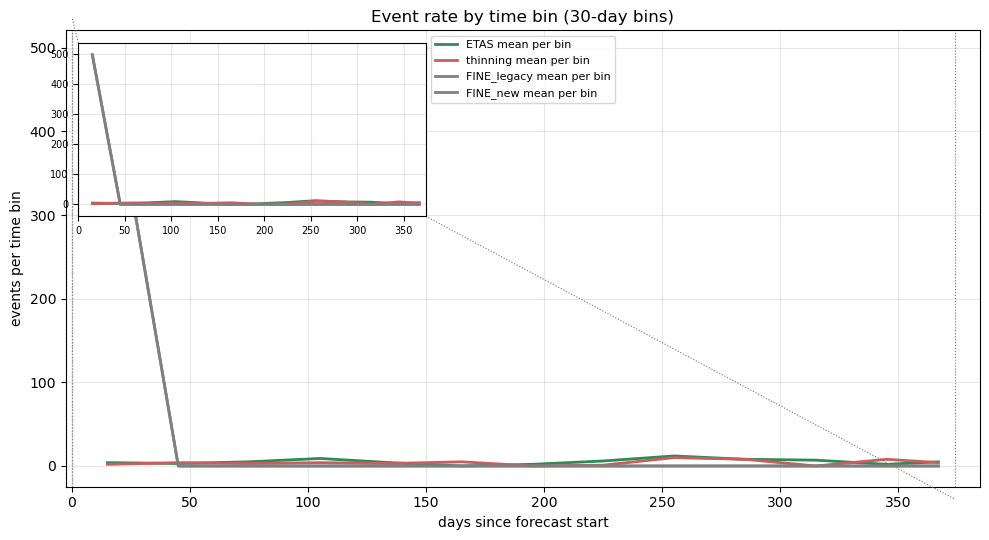

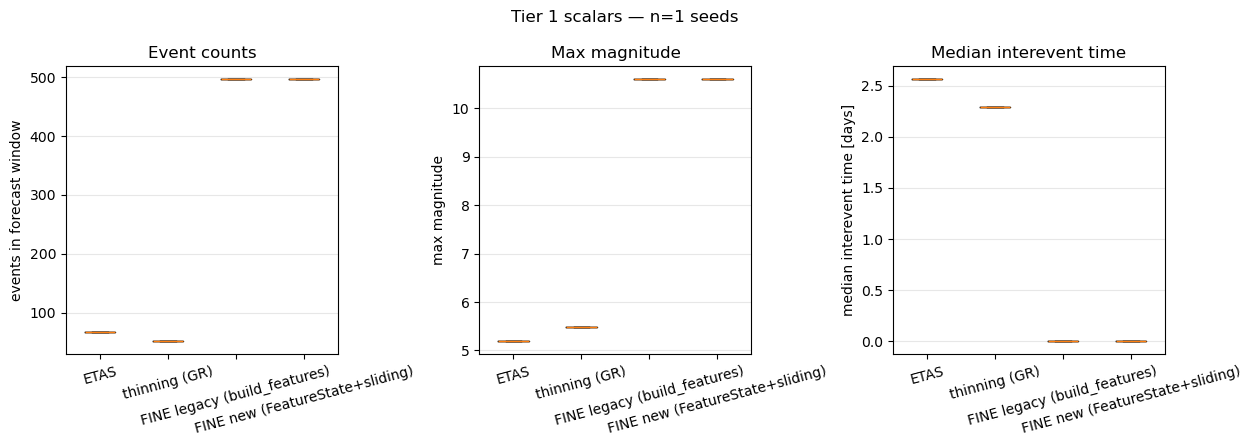

In [6]:
try:
    ctx = load_intensity_context(OUTPUT_ROOT, primary_dir, primary_meta, selected_seeds[0])
    mc_val = float(ctx["mc"])
    beta_val = float(ctx["beta"])
    forecast_days = float(ctx["forecast_days"])
    actual_test_dt_days = ctx["actual_test_dt_days"]
    actual_test_m = ctx["actual_test_m"]
    timewindow_start = ctx.get("timewindow_start")
    timewindow_end = ctx.get("timewindow_end")
    train_dt_days = np.array([], dtype=float)
    train_days = 0.0
    if timewindow_start and timewindow_end:
        train_start_dt = pd.to_datetime(timewindow_start, utc=True).tz_convert(None)
        train_end_dt = pd.to_datetime(timewindow_end, utc=True).tz_convert(None)
        train_df = ctx["history_df"].loc[
            (ctx["history_df"]["time"] >= train_start_dt)
            & (ctx["history_df"]["time"] <= train_end_dt)
        ]
        train_dt_days = train_df["t"].to_numpy(dtype=float) - ctx["forecast_start_t"]
        train_days = float((train_end_dt - train_start_dt).total_seconds() / 86400.0)
except Exception as exc:
    display(Markdown(f"_Could not load inversion context ({exc}); using catalog times only._"))
    all_dt = np.concatenate(
        [cat["dt_days"].to_numpy() for catalogs in catalogs_by_method.values() for cat in catalogs.values()]
    )
    forecast_days = float(np.nanmax(all_dt)) if all_dt.size else 1.0
    train_dt_days = np.array([], dtype=float)
    actual_test_dt_days = np.array([], dtype=float)
    actual_test_m = np.array([], dtype=float)
    train_days = 0.0
    mc_val = float("nan")
    beta_val = float("nan")

t_grid = np.linspace(-train_days, forecast_days, 200)
curves_by_method = {
    method: np.vstack(
        [cumulative_on_grid(catalogs[s]["dt_days"].to_numpy(), t_grid) for s in selected_seeds]
    )
    for method, catalogs in catalogs_by_method.items()
}
forecast_mask = t_grid >= 0.0
slopes_by_method = {
    method: float(np.polyfit(t_grid[forecast_mask], arr.mean(axis=0)[forecast_mask], 1)[0])
    for method, arr in curves_by_method.items()
}

cum_ylim_curves = [arr.mean(axis=0) for arr in curves_by_method.values()]
for arr in curves_by_method.values():
    if arr.shape[0] > 1:
        q25, q75 = np.quantile(arr, [0.25, 0.75], axis=0)
        cum_ylim_curves.extend([q25, q75])
if actual_test_dt_days.size:
    cum_ylim_curves.append(cumulative_on_grid(actual_test_dt_days, t_grid))
cum_test_ylims = ylim_in_xrange(t_grid, cum_ylim_curves, 0.0, forecast_days)

fig, ax = plt.subplots(figsize=(10, 5.5))
draw_cumulative_event_count(
    ax,
    t_grid=t_grid,
    curves_by_method=curves_by_method,
    slopes_by_method=slopes_by_method,
    train_dt_days=train_dt_days,
    actual_test_dt_days=actual_test_dt_days,
    train_days=train_days,
    show_training_slopes=True,
    show_legend=True,
)
ax.set_xlabel("days since forecast start")
ax.set_ylabel("cumulative number of events N(t)")
ax.set_title(f"Cumulative event count — {', '.join(METHOD_LABELS[m] for m in methods)}")
ax.grid(True, alpha=0.3)
ax.legend(fontsize=8)
add_test_window_inset(
    ax,
    forecast_days,
    lambda axins: draw_cumulative_event_count(
        axins,
        t_grid=t_grid,
        curves_by_method=curves_by_method,
        slopes_by_method=slopes_by_method,
        train_dt_days=train_dt_days,
        actual_test_dt_days=actual_test_dt_days,
        train_days=train_days,
        show_training_slopes=False,
        show_legend=False,
    ),
    ylims=cum_test_ylims,
)
fig.tight_layout()
show_fig(fig)

BIN_LENGTH_DAYS = 30.0
t_min, t_max = -train_days, forecast_days
negative_edges = -np.arange(0.0, train_days + BIN_LENGTH_DAYS, BIN_LENGTH_DAYS)[::-1]
negative_edges = negative_edges[negative_edges >= t_min]
if negative_edges.size == 0 or negative_edges[0] > t_min:
    negative_edges = np.insert(negative_edges, 0, t_min)
positive_edges = np.arange(0.0, forecast_days + BIN_LENGTH_DAYS, BIN_LENGTH_DAYS)
positive_edges = positive_edges[positive_edges <= t_max]
if positive_edges.size == 0 or positive_edges[-1] < t_max:
    positive_edges = np.append(positive_edges, t_max)
bin_edges = np.unique(np.concatenate((negative_edges, positive_edges)))
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
bin_curves_by_method = {
    method: np.vstack(
        [events_per_time_bin(catalogs[s]["dt_days"].to_numpy(), bin_edges) for s in selected_seeds]
    )
    for method, catalogs in catalogs_by_method.items()
}
bin_ylim_curves = [arr.mean(axis=0) for arr in bin_curves_by_method.values()]
for arr in bin_curves_by_method.values():
    if arr.shape[0] > 1:
        q25, q75 = np.quantile(arr, [0.25, 0.75], axis=0)
        bin_ylim_curves.extend([q25, q75])
if actual_test_dt_days.size:
    bin_ylim_curves.append(events_per_time_bin(actual_test_dt_days, bin_edges))
bin_test_ylims = ylim_in_xrange(bin_centers, bin_ylim_curves, 0.0, forecast_days)

fig, ax = plt.subplots(figsize=(10, 5.5))
draw_event_rate_by_bin(
    ax,
    bin_centers=bin_centers,
    bin_edges=bin_edges,
    bin_curves_by_method=bin_curves_by_method,
    train_dt_days=train_dt_days,
    actual_test_dt_days=actual_test_dt_days,
    include_training=True,
    show_legend=True,
)
ax.set_xlabel("days since forecast start")
ax.set_ylabel("events per time bin")
ax.set_title(f"Event rate by time bin ({BIN_LENGTH_DAYS:g}-day bins)")
ax.grid(True, alpha=0.3)
ax.legend(fontsize=8)
add_test_window_inset(
    ax,
    forecast_days,
    lambda axins: draw_event_rate_by_bin(
        axins,
        bin_centers=bin_centers,
        bin_edges=bin_edges,
        bin_curves_by_method=bin_curves_by_method,
        train_dt_days=train_dt_days,
        actual_test_dt_days=actual_test_dt_days,
        include_training=False,
        show_legend=False,
    ),
    ylims=bin_test_ylims,
)
fig.tight_layout()
show_fig(fig)

# Scalar boxplots
n_panels = 3
fig, axes = plt.subplots(1, n_panels, figsize=(4.2 * n_panels, 4.5))
count_series = [paired_metrics[f"{m}_n_events"] for m in methods]
axes[0].boxplot(count_series, tick_labels=[METHOD_LABELS[m] for m in methods])
axes[0].set_ylabel("events in forecast window")
axes[0].set_title("Event counts")
axes[0].tick_params(axis="x", rotation=15)
axes[0].grid(True, alpha=0.3, axis="y")

max_m_series = [paired_metrics[f"{m}_max_magnitude"] for m in methods]
axes[1].boxplot(max_m_series, tick_labels=[METHOD_LABELS[m] for m in methods])
axes[1].set_ylabel("max magnitude")
axes[1].set_title("Max magnitude")
axes[1].tick_params(axis="x", rotation=15)
axes[1].grid(True, alpha=0.3, axis="y")

iet_series = [paired_metrics[f"{m}_median_iet_days"] for m in methods]
axes[2].boxplot(iet_series, tick_labels=[METHOD_LABELS[m] for m in methods])
axes[2].set_ylabel("median interevent time [days]")
axes[2].set_title("Median interevent time")
axes[2].tick_params(axis="x", rotation=15)
axes[2].grid(True, alpha=0.3, axis="y")

fig.suptitle(f"Tier 1 scalars — n={len(selected_seeds)} seeds", fontsize=12)
fig.tight_layout()
show_fig(fig)


## Tier 2 — pooled magnitude and interevent-time distributions


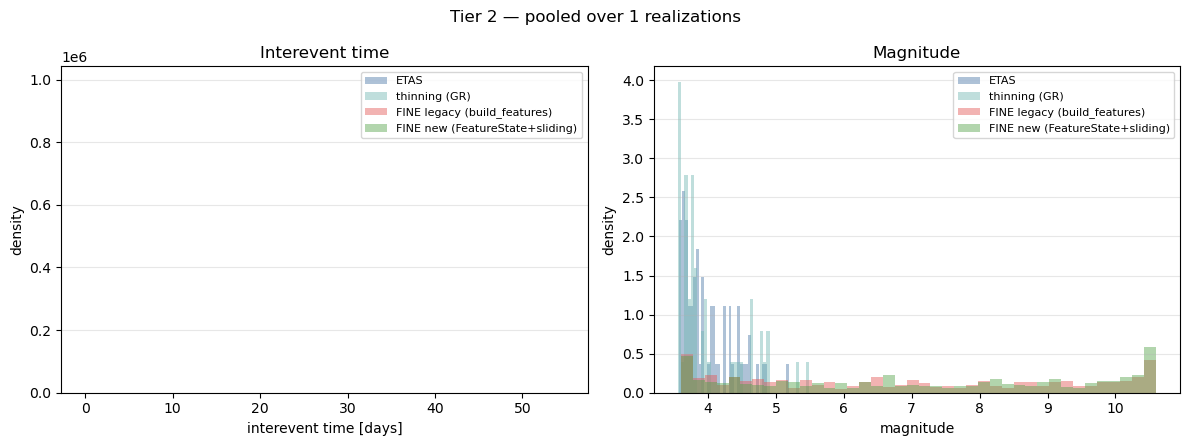

**Tier 2 — pairwise KS tests:**

,comparison,quantity,KS statistic,p-value
0,ETAS vs thinning (GR),interevent time,0.133690,6.236258e-01
1,ETAS vs thinning (GR),magnitude,0.162457,3.709322e-01
2,ETAS vs FINE legacy (build_features),interevent time,0.989899,2.813105e-80
3,ETAS vs FINE legacy (build_features),magnitude,0.708865,7.793538e-30
4,ETAS vs FINE new (FeatureState+sliding),interevent time,0.989899,2.813105e-80
5,ETAS vs FINE new (FeatureState+sliding),magnitude,0.749188,6.249561e-34
6,thinning (GR) vs FINE legacy (build_features),interevent time,0.993939,2.169297e-68
7,thinning (GR) vs FINE legacy (build_features),magnitude,0.681297,6.522144e-22
8,thinning (GR) vs FINE new (FeatureState+sliding),interevent time,0.993939,2.169297e-68
9,thinning (GR) vs FINE new (FeatureState+sliding),magnitude,0.719603,8.177250e-25


In [7]:
pooled_iet = {
    method: np.concatenate(
        [interevent_times(catalogs[s]["dt_days"].to_numpy(dtype=float)) for s in selected_seeds]
    )
    for method, catalogs in catalogs_by_method.items()
}
pooled_m = {}
for method, catalogs in catalogs_by_method.items():
    m_all = np.concatenate([catalogs[s]["m"].to_numpy(dtype=float) for s in selected_seeds])
    if np.isfinite(mc_val):
        m_all = m_all[m_all >= mc_val]
    pooled_m[method] = m_all

test_iet = interevent_times(np.asarray(actual_test_dt_days, dtype=float))
test_m = np.asarray(actual_test_m, dtype=float)
if np.isfinite(mc_val) and test_m.size:
    test_m = test_m[test_m >= mc_val]

_IET_BINS = 50
_MAG_BINS = 40
_TEST_HIST_KW = {
    "density": True,
    "histtype": "step",
    "linewidth": 2.0,
    "color": "black",
    "zorder": 5,
}

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for method in methods:
    if pooled_iet[method].size:
        axes[0].hist(
            pooled_iet[method],
            bins=_IET_BINS,
            density=True,
            alpha=0.45,
            color=METHOD_COLORS[method],
            label=METHOD_LABELS[method],
        )
    if pooled_m[method].size:
        axes[1].hist(
            pooled_m[method],
            bins=_MAG_BINS,
            density=True,
            alpha=0.45,
            color=METHOD_COLORS[method],
            label=METHOD_LABELS[method],
        )
if test_iet.size:
    axes[0].hist(
        test_iet,
        bins=_IET_BINS,
        label=f"Actual test catalog (n={test_iet.size})",
        **_TEST_HIST_KW,
    )
if test_m.size:
    axes[1].hist(
        test_m,
        bins=_MAG_BINS,
        label=f"Actual test catalog (n={test_m.size})",
        **_TEST_HIST_KW,
    )
axes[0].set_xlabel("interevent time [days]")
axes[0].set_ylabel("density")
axes[0].set_title("Interevent time")
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3, axis="y")
axes[1].set_xlabel(f"magnitude (≥ mc={mc_val:.2f})" if np.isfinite(mc_val) else "magnitude")
axes[1].set_ylabel("density")
axes[1].set_title("Magnitude")
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3, axis="y")
fig.suptitle(f"Tier 2 — pooled over {len(selected_seeds)} realizations", fontsize=12)
fig.tight_layout()
show_fig(fig)

if len(methods) >= 2:
    ks_rows = []
    for i, ma in enumerate(methods):
        for mb in methods[i + 1 :]:
            for name, store in [("interevent time", pooled_iet), ("magnitude", pooled_m)]:
                a_data, b_data = store[ma], store[mb]
                if a_data.size and b_data.size:
                    stat, pval = stats.ks_2samp(a_data, b_data)
                    ks_rows.append(
                        {
                            "comparison": f"{METHOD_LABELS[ma]} vs {METHOD_LABELS[mb]}",
                            "quantity": name,
                            "KS statistic": stat,
                            "p-value": pval,
                        }
                    )
    display(Markdown("**Tier 2 — pairwise KS tests:**"))
    display(pd.DataFrame(ks_rows))


## Formal tests (when ≥ 2 methods)


In [8]:
if len(methods) < 2:
    display(Markdown("_Fewer than 2 methods — skip paired formal tests._"))
else:
    formal_rows = []
    n_perm = 5000
    rng = np.random.default_rng(0)
    for i, ma in enumerate(methods):
        for mb in methods[i + 1 :]:
            a_counts = paired_metrics[f"{ma}_n_events"].to_numpy(dtype=float)
            b_counts = paired_metrics[f"{mb}_n_events"].to_numpy(dtype=float)
            paired_diff = b_counts - a_counts
            if len(selected_seeds) >= 2 and np.any(paired_diff != 0):
                w_stat, w_p = stats.wilcoxon(b_counts, a_counts)
            else:
                w_stat, w_p = np.nan, np.nan
            if len(selected_seeds) >= 2:
                pr, pp = stats.pearsonr(a_counts, b_counts)
            else:
                pr, pp = np.nan, np.nan
            obs = float(paired_diff.mean())
            perm = np.empty(n_perm)
            for k in range(n_perm):
                signs = rng.choice([-1.0, 1.0], size=len(paired_diff))
                perm[k] = (signs * paired_diff).mean()
            perm_p = float((np.abs(perm) >= abs(obs)).mean())
            label = f"{METHOD_LABELS[ma]} vs {METHOD_LABELS[mb]}"
            formal_rows.extend(
                [
                    {"pair": label, "test": "Paired Wilcoxon (counts)", "statistic": w_stat, "p-value": w_p},
                    {"pair": label, "test": "Pearson r (counts)", "statistic": pr, "p-value": pp},
                    {"pair": label, "test": "Permutation mean Δcount", "statistic": obs, "p-value": perm_p},
                ]
            )
    display(Markdown("**Formal tests:**"))
    display(pd.DataFrame(formal_rows))


**Formal tests:**

,pair,test,statistic,p-value
0,ETAS vs thinning (GR),Paired Wilcoxon (counts),NaN,NaN
1,ETAS vs thinning (GR),Pearson r (counts),NaN,NaN
2,ETAS vs thinning (GR),Permutation mean Δcount,-15.0,1.0
3,ETAS vs FINE legacy (build_features),Paired Wilcoxon (counts),NaN,NaN
4,ETAS vs FINE legacy (build_features),Pearson r (counts),NaN,NaN
5,ETAS vs FINE legacy (build_features),Permutation mean Δcount,429.0,1.0
6,ETAS vs FINE new (FeatureState+sliding),Paired Wilcoxon (counts),NaN,NaN
7,ETAS vs FINE new (FeatureState+sliding),Pearson r (counts),NaN,NaN
8,ETAS vs FINE new (FeatureState+sliding),Permutation mean Δcount,429.0,1.0
9,thinning (GR) vs FINE legacy (build_features),Paired Wilcoxon (counts),NaN,NaN


## MAGNET Kumaraswamy forecast samples

Shown when `thinning_magnet` / FINE is loaded. Kumaraswamy PDFs need a
`magnet_predictions.npz` sidecar for the chosen seed (enable with
`magnet.save_predictions` or `--save-magnet-predictions`). The magnitude–time
scatter below still uses the FINE forecast seed even without a sidecar.

Control via the **User config** cell:

| Setting | Meaning |
|---|---|
| `MAGNET_PRED_SEED` | FINE forecast seed to inspect (`None` → first loaded FINE seed) |
| `SHOW_ACTUAL_CONTINUATION` | Overlay observed catalog in the continuation window on the mag–time scatter |
| `MAGNET_SCATTER_INTERACTIVE` | Plotly zoom/pan for the mag–time scatter (`False` → static matplotlib) |
| `KUMA_EVENT_MODE` | `indices` / `largest_m` / `first_n` / `magnitude_range` |
| `KUMA_EVENT_INDICES` | Explicit 0-based row indices (when mode=`indices`) |
| `KUMA_N_EVENTS` | How many PDFs to draw |
| `KUMA_MAG_RANGE` | Magnitude window for `magnitude_range` |

Row index `i` refers to the `i`-th entry in `magnet_predictions.npz` (aligned with
forecast order; `event_index` in the sidecar may be constant when MAGNET is called
one event at a time).


In [9]:
HAS_MAGNET = MAGNET_METHOD in catalogs_by_method
magnet_preds = None
magnet_seed_used = None
magnet_run_dir = None
event_ids: list[int] = []

if not HAS_MAGNET:
    display(Markdown(f"_`{MAGNET_METHOD}` not in methods — skip MAGNET detail panels._"))
else:
    magnet_dir = ensemble_dirs[MAGNET_METHOD]
    # Default to the FINE forecast realization under inspection (not "first with sidecar").
    if MAGNET_PRED_SEED is not None:
        if MAGNET_PRED_SEED not in selected_seeds:
            raise ValueError(
                f"MAGNET_PRED_SEED={MAGNET_PRED_SEED} not in loaded FINE seeds "
                f"{selected_seeds}"
            )
        magnet_seed_used = int(MAGNET_PRED_SEED)
    else:
        magnet_seed_used = int(selected_seeds[0])
        display(Markdown(
            f"_`MAGNET_PRED_SEED` unset → using FINE forecast seed "
            f"`{magnet_seed_used}` (first loaded realization)._"
        ))

    magnet_run_dir = realization_dir(magnet_dir, magnet_seed_used)
    magnet_preds = load_magnet_predictions(magnet_run_dir)
    mag_meta = metas_by_method[MAGNET_METHOD]
    model_dir = (
        Path(mag_meta["thinning_model_dir"]) if mag_meta.get("thinning_model_dir") else None
    )
    display(Markdown(
        f"**FINE / MAGNET realization:** seed `{magnet_seed_used}` → `{magnet_run_dir}`"
    ))
    if model_dir is not None:
        display(Markdown(f"**MAGNET model (from FINE meta):** `{model_dir}`"))

    if magnet_preds is None:
        display(Markdown(
            f"_No `{_MAGNET_PREDICTIONS_NAME}` for seed `{magnet_seed_used}` under "
            f"`{magnet_dir}`. Kumaraswamy PDFs skipped; magnitude–time still uses "
            f"this FINE seed. Re-run with `--save-magnet-predictions` to enable PDFs._"
        ))
    else:
        display(Markdown(
            f"**MAGNET predictions:** `{magnet_run_dir / _MAGNET_PREDICTIONS_NAME}` "
            f"({len(magnet_preds['magnitude'])} rows)"
        ))

        shift, stretch = parse_magnet_shift_stretch(model_dir, mc_val)
        display(Markdown(f"PDF support: shift (mc) = `{shift}`, stretch = `{stretch}`"))

        mags = np.asarray(magnet_preds["magnitude"], dtype=float)
        preds_arr = np.asarray(magnet_preds["model_prediction"])
        _kuma_n_panels = 6
        _kuma_log_indices = np.unique(
            np.round(np.geomspace(1, len(mags), num=_kuma_n_panels)).astype(int) - 1
        ).tolist()
        event_ids = select_kuma_event_indices(
            mags,
            mode='indices',
            indices=_kuma_log_indices,
            n_events=100,
            mag_range=[0,10],
        )
        # event_ids = select_kuma_event_indices(
        #     mags,
        #     mode=KUMA_EVENT_MODE,
        #     indices=KUMA_EVENT_INDICES,
        #     n_events=KUMA_N_EVENTS,
        #     mag_range=KUMA_MAG_RANGE,
        # )
        display(Markdown(
            f"**Selected events** (`{KUMA_EVENT_MODE}`): `{event_ids}` — "
            f"magnitudes `{[round(float(mags[i]), 3) for i in event_ids]}`"
        ))

        # Catalog alignment for annotation (forecast may be longer if truncated mid-run).
        catalog = catalogs_by_method[MAGNET_METHOD][magnet_seed_used]
        n_align = min(len(catalog), len(mags))

        if KUMA_M_GRID is None:
            m_lo = float(shift)
            m_hi = float(shift + stretch)
            n_grid = 400
        else:
            m_lo, m_hi, n_grid = KUMA_M_GRID
        m_grid = np.linspace(m_lo, m_hi, int(n_grid))
        gr_pdf = (
            beta_val * np.exp(-beta_val * (m_grid - shift))
            if np.isfinite(beta_val) and beta_val > 0
            else None
        )

        n_show = len(event_ids)
        n_cols = min(3, max(1, n_show))
        n_rows = int(math.ceil(n_show / n_cols)) if n_show else 1
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(4.2 * n_cols, 3.4 * n_rows), squeeze=False)
        for ax in axes.ravel():
            ax.set_visible(False)

        for panel_i, event_i in enumerate(event_ids):
            ax = axes[panel_i // n_cols][panel_i % n_cols]
            ax.set_visible(True)
            pred_row = preds_arr[event_i]
            pdf = magnitude_pdf_from_prediction(m_grid, pred_row, shift=shift, stretch=stretch)
            ax.plot(
                m_grid,
                pdf,
                color=METHOD_COLORS[MAGNET_METHOD],
                lw=2.0,
                label="MAGNET",
            )
            if gr_pdf is not None:
                b_value = beta_val / np.log(10.0)
                ax.plot(
                    m_grid,
                    gr_pdf,
                    color=METHOD_COLORS.get("etas", "tab:blue"),
                    ls="--",
                    lw=1.8,
                    label=f"GR (b={b_value:.2f})",
                )
            sampled_m = float(mags[event_i])
            ax.axvline(sampled_m, color="black", ls="--", lw=1.2, label=f"sampled m={sampled_m:.2f}")
            if event_i < n_align:
                cat_m = float(catalog.iloc[event_i]["m"])
                if abs(cat_m - sampled_m) > 1e-3:
                    ax.axvline(cat_m, color="gray", ls=":", lw=1.0, label=f"catalog m={cat_m:.2f}")
            lon = float(magnet_preds["longitude"][event_i])
            lat = float(magnet_preds["latitude"][event_i])
            ax.set_title(f"event row {event_i}\n({lat:.3f}, {lon:.3f})", fontsize=9)
            ax.set_xlabel("magnitude")
            ax.set_ylabel("pdf")
            ax.set_yscale("log")
            ax.grid(True, alpha=0.3, which="both")
            ax.legend(fontsize=7)

        fig.suptitle(
            f"MAGNET Kumaraswamy mixture PDFs — seed {magnet_seed_used}",
            fontsize=12,
        )
        fig.tight_layout()
        show_fig(fig)

        rows = []
        for event_i in event_ids:
            rows.append(
                {
                    "row": event_i,
                    "magnitude": float(mags[event_i]),
                    "latitude": float(magnet_preds["latitude"][event_i]),
                    "longitude": float(magnet_preds["longitude"][event_i]),
                    "time_unix": int(magnet_preds["time"][event_i]),
                    "pred_params": np.asarray(preds_arr[event_i]).tolist(),
                }
            )
        display(Markdown("**Selected events (set `KUMA_EVENT_MODE='indices'` + `KUMA_EVENT_INDICES` to lock these):**"))
        display(pd.DataFrame(rows).drop(columns=["pred_params"]))


**FINE / MAGNET realization:** seed `0` → `/home/neriberman/Repos/etas-fine-speed-gpu/outputs/etas_thinning_fine_fast_tracks/FINE_legacy/FINE/inv_a03d7b966a77d150/seed_0`

**MAGNET model (from FINE meta):** `/home/neriberman/Repos/etas-fine-speed-gpu/outputs/fine_speed_benchmark/20260915_legacy_vs_new/shared/magnet/model_354944a6fdb44b2ea68eec83e96fa4b7473fc557/_repetition_0`

_No `magnet_predictions.npz` for seed `0` under `/home/neriberman/Repos/etas-fine-speed-gpu/outputs/etas_thinning_fine_fast_tracks/FINE_legacy/FINE/inv_a03d7b966a77d150`. Kumaraswamy PDFs skipped; magnitude–time still uses this FINE seed. Re-run with `--save-magnet-predictions` to enable PDFs._

## MAGNET Kumaraswamy parameters vs time

For the **same realization** used in the Kumaraswamy PDF panels above (`magnet_seed_used`),
plot mixture parameters (`a[k]`, `b[k]`, `w[k]` for each component `k`) vs event time.

Tune `MAGNET_PARAMS_EVENT_STRIDE` to thin dense catalogs.

In [10]:
if magnet_seed_used is None or magnet_preds is None:
    display(Markdown("_No MAGNET realization selected above — skip parameter time series._"))
else:
    n_events = len(magnet_preds["magnitude"])
    n_comp = int(np.asarray(magnet_preds["model_prediction"]).shape[-1] // 3)
    display(Markdown(
        f"**Kumaraswamy parameters:** seed `{magnet_seed_used}`, "
        f"{n_comp} component(s), {n_events} events"
    ))
    fig = plot_kumaraswamy_params_vs_time(
        magnet_preds,
        event_stride=MAGNET_PARAMS_EVENT_STRIDE,
        title=f"MAGNET Kumaraswamy parameters — seed {magnet_seed_used}",
    )
    if fig is not None:
        show_fig(fig)


_No MAGNET realization selected above — skip parameter time series._

## MAGNET realization — magnitude vs time

Uses the FINE forecast seed selected above (`magnet_seed_used`, from `MAGNET_PRED_SEED`
or the first loaded FINE seed). One **stacked subplot per method** (shared date axis),
each showing the pre-continuation catalog, simulated continuation, and optionally the
observed continuation (`SHOW_ACTUAL_CONTINUATION`). PDF event highlights appear on the
MAGNET panel only when `magnet_predictions.npz` was available.

With `MAGNET_SCATTER_INTERACTIVE=True` (default), this cell renders an **interactive Plotly**
figure (box-zoom / double-click reset). Set it to `False` for static matplotlib.


_Could not load pre-continuation / observed catalog (/home/neriberman/Repos/etas-fine-speed-gpu/outputs/etas_thinning_fine_fast_tracks/inversions/inv_a03d7b966a77d150/parameters_a03d7b966a77d150.json)._

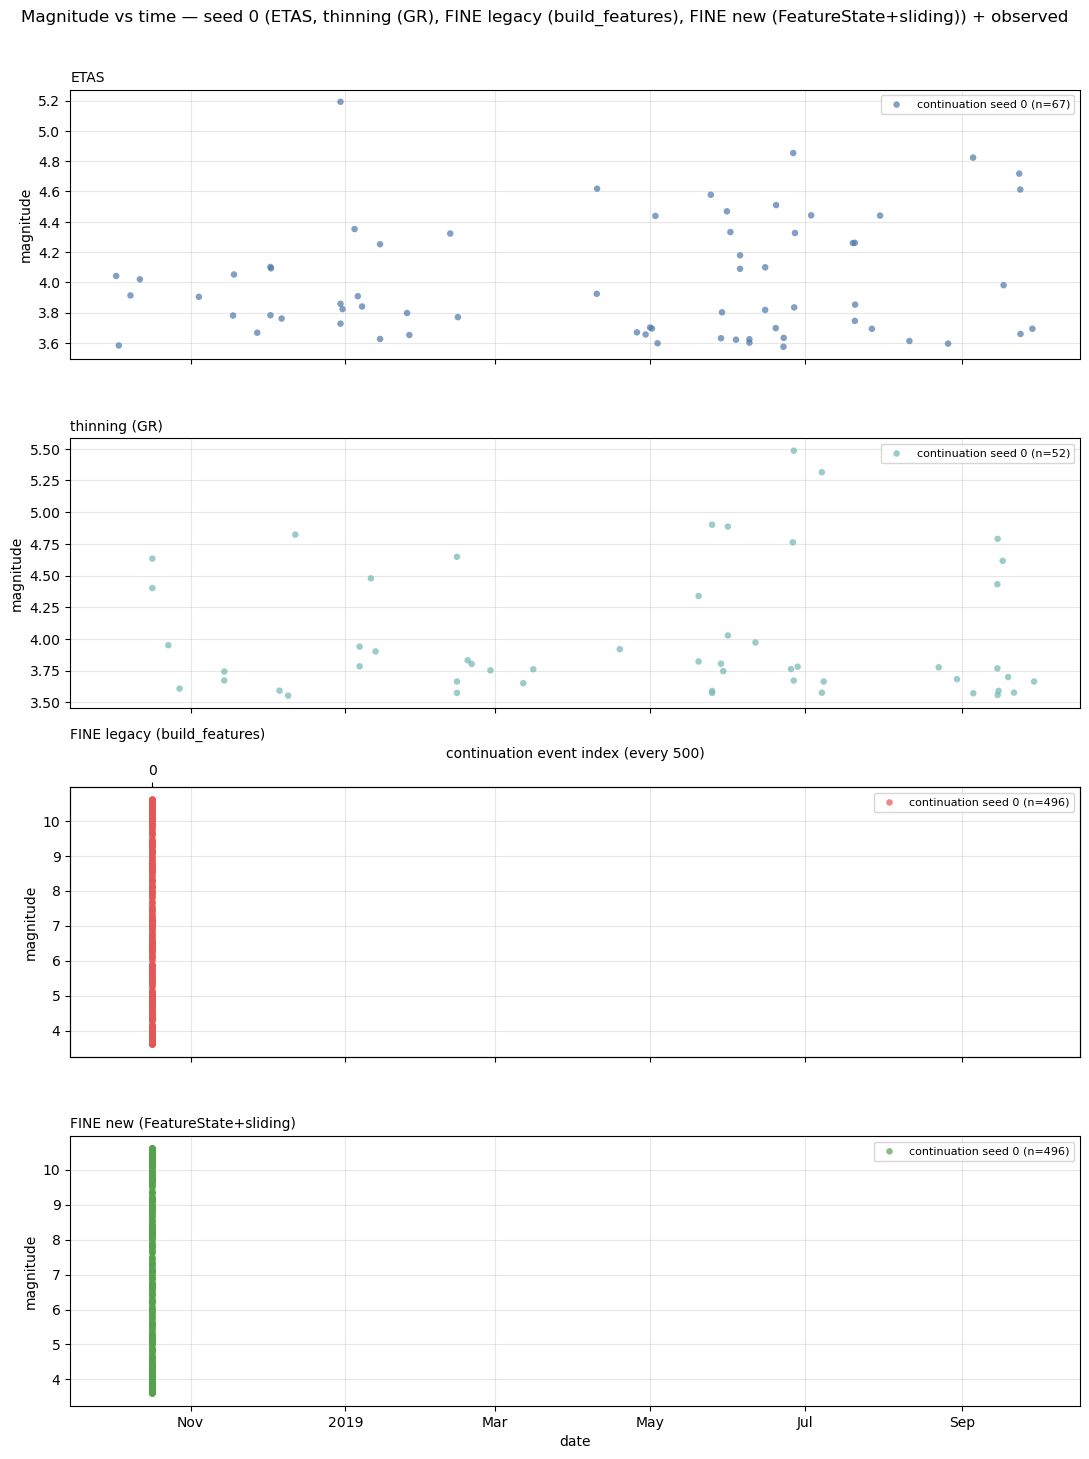

In [11]:
if magnet_seed_used is None:
    display(Markdown("_No FINE/MAGNET realization selected above — skip magnitude–time scatter._"))
else:
    def _catalog_times_and_mags(catalog: pd.DataFrame, forecast_start: pd.Timestamp | None):
        return data_utils.catalog_times_and_mags(catalog, forecast_start)

    def _pick_times(times, indices):
        if hasattr(times, "iloc"):
            return times.iloc[indices]
        return times[indices]

    # Pre-continuation + optional observed continuation from intensity context.
    hist_times = pd.Series(dtype="datetime64[ns]")
    hist_m = np.array([], dtype=float)
    actual_times = pd.Series(dtype="datetime64[ns]")
    actual_m = np.array([], dtype=float)
    forecast_start_dt = None
    try:
        _ctx = ctx if "ctx" in globals() and isinstance(ctx, dict) and "history_df" in ctx else None
        if _ctx is None:
            _ctx = load_intensity_context(
                OUTPUT_ROOT,
                ensemble_dirs[MAGNET_METHOD],
                metas_by_method[MAGNET_METHOD],
                magnet_seed_used,
            )
        history_df = _ctx["history_df"]
        forecast_start_t = float(_ctx["forecast_start_t"])
        forecast_start_dt = pd.Timestamp("1970-01-01") + pd.to_timedelta(forecast_start_t, unit="D")
        tw_start = _ctx.get("timewindow_start")
        tw_end = _ctx.get("timewindow_end")
        hist = history_df
        if tw_start and tw_end:
            train_start_dt = pd.to_datetime(tw_start, utc=True).tz_convert(None)
            train_end_dt = pd.to_datetime(tw_end, utc=True).tz_convert(None)
            hist = history_df.loc[
                (history_df["time"] >= train_start_dt) & (history_df["time"] <= train_end_dt)
            ]
            forecast_start_dt = train_end_dt
        hist_times = pd.to_datetime(hist["time"], utc=True).dt.tz_convert(None)
        hist_m = hist["magnitude"].to_numpy(dtype=float)
        if SHOW_ACTUAL_CONTINUATION:
            actual_dt_days = np.asarray(_ctx.get("actual_test_dt_days", []), dtype=float)
            actual_m = np.asarray(_ctx.get("actual_test_m", []), dtype=float)
            if (
                actual_dt_days.size
                and actual_m.size == actual_dt_days.size
                and forecast_start_dt is not None
            ):
                actual_times = forecast_start_dt + pd.to_timedelta(actual_dt_days, unit="D")
            elif actual_dt_days.size and actual_m.size == 0:
                display(Markdown(
                    "_`SHOW_ACTUAL_CONTINUATION=True` but `actual_test_m` missing — "
                    "re-run the helpers cell to refresh `load_intensity_context`._"
                ))
    except Exception as exc:
        display(Markdown(f"_Could not load pre-continuation / observed catalog ({exc})._"))

    method_layers: dict[str, tuple[pd.Series | pd.DatetimeIndex, np.ndarray]] = {}
    for method in methods:
        method_catalogs = catalogs_by_method.get(method, {})
        if magnet_seed_used not in method_catalogs:
            continue
        method_layers[method] = _catalog_times_and_mags(
            method_catalogs[magnet_seed_used],
            forecast_start_dt,
        )
    if not method_layers:
        raise ValueError(f"No forecast catalogs loaded for seed {magnet_seed_used}")

    magnet_cat = catalogs_by_method[MAGNET_METHOD][magnet_seed_used]
    highlight_ids = list(event_ids) if "event_ids" in globals() and event_ids else []
    highlight_ids = [i for i in highlight_ids if 0 <= i < len(magnet_cat)]
    idx_step = 500
    magnet_times, _ = method_layers[MAGNET_METHOD]
    idx_ticks = list(range(0, len(magnet_cat), idx_step))
    method_part = ", ".join(METHOD_LABELS[m] for m in method_layers)
    title = (
        f"Magnitude vs time — seed {magnet_seed_used} ({method_part})"
        + (" + observed" if SHOW_ACTUAL_CONTINUATION else "")
    )

    def _draw_method_panel(
        ax,
        method: str,
        cont_times,
        cont_mags: np.ndarray,
        *,
        show_xlabel: bool,
        show_idx_axis: bool,
    ):
        import matplotlib.dates as mdates

        if len(hist_times):
            ax.scatter(
                hist_times,
                hist_m,
                s=14,
                alpha=0.2,
                color="0.45",
                edgecolors="none",
                label=f"pre-continuation (n={len(hist_times)})",
                zorder=1,
            )
        if SHOW_ACTUAL_CONTINUATION and len(actual_times) and actual_m.size == len(actual_times):
            ax.scatter(
                actual_times,
                actual_m,
                s=22,
                alpha=0.3,
                color="darkorange",
                edgecolors="none",
                marker="D",
                label=f"observed continuation (n={len(actual_times)})",
                zorder=2,
            )
        ax.scatter(
            cont_times,
            cont_mags,
            s=22,
            alpha=0.7,
            color=METHOD_COLORS[method],
            edgecolors="none",
            label=f"continuation seed {magnet_seed_used} (n={len(cont_mags)})",
            zorder=3,
        )
        if method == MAGNET_METHOD and highlight_ids:
            ax.scatter(
                _pick_times(cont_times, highlight_ids),
                cont_mags[highlight_ids],
                s=90,
                facecolors="none",
                edgecolors="black",
                linewidths=1.4,
                label=f"PDF panels ({len(highlight_ids)})",
                zorder=4,
            )
            for i in highlight_ids:
                ax.annotate(
                    str(i),
                    (mdates.date2num(_pick_times(cont_times, [i])[0]), cont_mags[i]),
                    textcoords="offset points",
                    xytext=(4, 4),
                    fontsize=8,
                    zorder=5,
                )
        if forecast_start_dt is not None:
            ax.axvline(forecast_start_dt, color="gray", ls=":", lw=1.0, alpha=0.8, zorder=0)
        if np.isfinite(mc_val):
            ax.axhline(mc_val, color="gray", ls=":", lw=1.0, label=f"mc={mc_val:.2f}")
        ax.set_ylabel("magnitude")
        ax.set_title(METHOD_LABELS[method], loc="left", fontsize=10)
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=8, loc="best")
        if show_xlabel:
            ax.set_xlabel("date")
            ax.xaxis.set_major_locator(mdates.AutoDateLocator())
            ax.xaxis.set_major_formatter(
                mdates.ConciseDateFormatter(ax.xaxis.get_major_locator())
            )
        else:
            ax.tick_params(labelbottom=False)
        if show_idx_axis:
            ax_idx = ax.twiny()
            ax_idx.set_xlim(ax.get_xlim())
            ax_idx.set_xticks([mdates.date2num(_pick_times(cont_times, [i])[0]) for i in idx_ticks])
            ax_idx.set_xticklabels([str(i) for i in idx_ticks])
            ax_idx.set_xlabel(f"continuation event index (every {idx_step})")

    def _matplotlib_mag_time():
        n_panels = len(method_layers)
        fig, axes = plt.subplots(
            n_panels,
            1,
            figsize=(11, max(3.6 * n_panels, 4.8)),
            sharex=True,
            squeeze=False,
        )
        for panel_i, (method, (cont_times, cont_mags)) in enumerate(method_layers.items()):
            ax = axes[panel_i, 0]
            _draw_method_panel(
                ax,
                method,
                cont_times,
                cont_mags,
                show_xlabel=panel_i == n_panels - 1,
                show_idx_axis=method == MAGNET_METHOD,
            )
        fig.suptitle(title, fontsize=12, y=1.01)
        fig.tight_layout()
        show_fig(fig)

    if MAGNET_SCATTER_INTERACTIVE:
        try:
            import plotly.graph_objects as go
            from IPython.display import HTML
            from plotly.subplots import make_subplots
        except ImportError as exc:
            display(Markdown(
                f"_Plotly not available in this kernel ({exc}). "
                "Falling back to static matplotlib. "
                "Install with: `python -m pip install plotly` in the notebook env._"
            ))
            _matplotlib_mag_time()
        else:
            n_panels = len(method_layers)
            fig = make_subplots(
                rows=n_panels,
                cols=1,
                shared_xaxes=True,
                subplot_titles=[
                    f"{METHOD_LABELS[method]} — seed {magnet_seed_used}"
                    for method in method_layers
                ],
                vertical_spacing=max(0.04, 0.12 / n_panels),
            )
            for row_i, (method, (cont_times, cont_mags)) in enumerate(
                method_layers.items(), start=1
            ):
                if len(hist_times):
                    fig.add_trace(
                        go.Scattergl(
                            x=pd.to_datetime(hist_times),
                            y=hist_m,
                            mode="markers",
                            name="pre-continuation" if row_i == 1 else None,
                            legendgroup="pre-continuation",
                            showlegend=row_i == 1,
                            marker=dict(size=4, color="rgba(120,120,120,0.35)"),
                        ),
                        row=row_i,
                        col=1,
                    )
                if (
                    SHOW_ACTUAL_CONTINUATION
                    and len(actual_times)
                    and actual_m.size == len(actual_times)
                ):
                    fig.add_trace(
                        go.Scattergl(
                            x=pd.to_datetime(actual_times),
                            y=actual_m,
                            mode="markers",
                            name="observed continuation" if row_i == 1 else None,
                            legendgroup="observed",
                            showlegend=row_i == 1,
                            marker=dict(
                                size=6,
                                color="rgba(255,140,0,0.45)",
                                symbol="diamond",
                            ),
                        ),
                        row=row_i,
                        col=1,
                    )
                fig.add_trace(
                    go.Scattergl(
                        x=pd.to_datetime(cont_times),
                        y=cont_mags,
                        mode="markers",
                        name=METHOD_LABELS[method],
                        legendgroup=method,
                        showlegend=True,
                        marker=dict(
                            size=6,
                            color=METHOD_COLORS[method],
                            opacity=0.75,
                        ),
                        customdata=np.arange(len(cont_mags)),
                        hovertemplate=(
                            "idx=%{customdata}<br>%{x}<br>m=%{y:.3f}<extra></extra>"
                        ),
                    ),
                    row=row_i,
                    col=1,
                )
                if method == MAGNET_METHOD and highlight_ids:
                    fig.add_trace(
                        go.Scatter(
                            x=pd.to_datetime(_pick_times(cont_times, highlight_ids)),
                            y=cont_mags[highlight_ids],
                            mode="markers+text",
                            name="PDF panels",
                            legendgroup="pdf-panels",
                            showlegend=True,
                            text=[str(i) for i in highlight_ids],
                            textposition="top center",
                            marker=dict(
                                size=12,
                                color="rgba(0,0,0,0)",
                                line=dict(width=2, color="black"),
                            ),
                        ),
                        row=row_i,
                        col=1,
                    )
                if forecast_start_dt is not None:
                    fig.add_vline(
                        x=forecast_start_dt,
                        line_dash="dot",
                        line_color="gray",
                        row=row_i,
                        col=1,
                    )
                if np.isfinite(mc_val):
                    fig.add_hline(
                        y=mc_val,
                        line_dash="dot",
                        line_color="gray",
                        annotation_text=f"mc={mc_val:.2f}" if row_i == 1 else None,
                        row=row_i,
                        col=1,
                    )

            fig.update_layout(
                title=title,
                height=max(320 * n_panels, 520),
                legend=dict(font=dict(size=10)),
                dragmode="zoom",
                margin=dict(t=90),
            )
            fig.update_yaxes(title_text="magnitude")
            fig.update_xaxes(title_text="date", type="date", row=n_panels, col=1)
            display(Markdown(
                "**Interactive Plotly figure** — drag to box-zoom, double-click to reset. "
                "Hover shows continuation event index on each method panel."
            ))
            display(HTML(fig.to_html(include_plotlyjs="cdn", full_html=False)))
    else:
        _matplotlib_mag_time()


## CSEP catalog-based tests (PL / N / M / S)

Compare each method's **full simulated catalog ensemble** against the observed test catalog using `csep.core.catalog_evaluations` (not the Poisson gridded-rate tests):

- **PL-test** — `pseudolikelihood_test()` (spatial pseudolikelihood; replaces the gridded Poisson L-test)
- **N-test** — `number_test()` (ensemble event-count distribution; pass when both tail probabilities exceed 0.05)
- **M-test** — `magnitude_test()` (scaled magnitude histogram vs ensemble mean)
- **S-test** — `spatial_test()` (normalized spatial likelihood)

For each method, all selected `seed_*` realizations are wrapped in a single `CatalogForecast` and evaluated once. This preserves spatial–temporal clustering in ETAS catalogs instead of collapsing them into independent Poisson spatial–magnitude bins.

In [12]:
from csep.core.regions import california_relm_region, create_space_magnitude_region
from shapely.geometry import Polygon as ShapelyPolygon
import etas.csep_utils as csep_utils

CSEP_LTEST_ALPHA = 0.025

# Inversions live under SHARED_ROOT (fast_tracks: .../shared; classic/standalone: OUTPUT_ROOT).
_csep_inv_root = SHARED_ROOT if "SHARED_ROOT" in globals() and SHARED_ROOT is not None else OUTPUT_ROOT
_, etas_inversion = csep_utils.load_inversion_for_csep(_csep_inv_root, inv_id)
m_ref = float(etas_inversion.m_ref)
study_poly = ShapelyPolygon(etas_inversion.shape_coords)
mag_bins = csep_utils.csep_magnitude_bins(etas_inversion)
csep_region = create_space_magnitude_region(california_relm_region(), mag_bins)

forecast_start = pd.to_datetime(primary_meta["timewindow_end"], utc=True).to_pydatetime()
forecast_end = pd.to_datetime(primary_meta["testwindow_end"], utc=True).to_pydatetime()

original_catalog_path = Path(etas_inversion.fn_catalog)
if not original_catalog_path.is_file():
    original_catalog_path = REPO_ROOT / "input_data" / original_catalog_path.name
observed_raw = pd.read_csv(original_catalog_path)
observed_raw["time"] = pd.to_datetime(observed_raw["time"], utc=True).dt.tz_convert(None)
forecast_start_dt = pd.to_datetime(primary_meta["timewindow_end"], utc=True).tz_convert(None)
forecast_end_dt = pd.to_datetime(primary_meta["testwindow_end"], utc=True).tz_convert(None)
observed_raw = observed_raw.loc[
    (observed_raw["time"] > forecast_start_dt)
    & (observed_raw["time"] <= forecast_end_dt)
].copy()
observed_filtered = csep_utils.filter_to_csep_region(
    observed_raw,
    region=csep_region,
    m_ref=m_ref,
    study_poly=study_poly,
)
observed_catalog = csep_utils.dataframe_to_csep_catalog(observed_filtered, catalog_id=0, region=csep_region)
observed_catalog.name = "observed_test_catalog"

display(
    Markdown(
        f"CSEP region: `{csep_region.name}` — {csep_region.num_nodes} spatial cells, "
        f"{len(csep_region.magnitudes)} magnitude bins from **m ≥ {m_ref:.2f}**; "
        f"observed test events in region: **{observed_catalog.event_count}**"
    )
)
if int(getattr(observed_catalog, "event_count", 0) or 0) == 0:
    display(Markdown(
        "_Observed catalog is empty — CSEP tests cannot run. Check forecast window "
        "vs `fn_catalog`, study polygon orientation, and `m_ref`._"
    ))
elif DATA_SOURCE == "fast_tracks" and len(selected_seeds) < 5:
    display(Markdown(
        "_Note: `fast_tracks` uses a short/capped ensemble. With few realizations, "
        "pyCSEP often drops all observed events as 'undersampled' and skips PL/N/M/S. "
        "Use `DATA_SOURCE='hauksson_classic'` for meaningful CSEP scores._"
    ))

csep_rows: list[dict] = []
l_test_results: dict[str, dict] = {}
for method, catalogs in catalogs_by_method.items():
    simulated_catalog_dfs = [catalogs[seed] for seed in selected_seeds]
    catalog_forecast = csep_utils.build_catalog_forecast_from_dataframes(
        simulated_catalog_dfs,
        name=METHOD_LABELS.get(method, method),
        region=csep_region,
        start_time=forecast_start,
        end_time=forecast_end,
        m_ref=m_ref,
        study_poly=study_poly,
    )
    if catalog_forecast is None:
        continue

    realization = METHOD_LABELS.get(method, method)
    if int(getattr(observed_catalog, "event_count", 0) or 0) == 0:
        display(Markdown(
            f"_Skip CSEP for `{realization}`: observed test catalog is empty "
            f"after region/magnitude filters._"
        ))
        continue
    try:
        scores = csep_utils.run_csep_catalog_tests(catalog_forecast, observed_catalog)
    except ValueError as err:
        # Common with tiny/capped ensembles: pyCSEP strips observed events that
        # fall in forecast cells with zero samples → PL-test returns None.
        display(Markdown(
            f"_Skip CSEP for `{realization}` ({catalog_forecast.n_cat} realization(s)): "
            f"{err}_"
        ))
        continue
    simulated_ll = scores.pop("simulated_ll")
    l_test_results[realization] = {
        "simulated_ll": simulated_ll,
        "observed_ll": scores["L_obs_ll"],
        "gamma": scores["L_quantile"],
    }
    csep_rows.append(
        {
            "method": method,
            "label": realization,
            "seed": "ensemble",
            "n_realizations": int(catalog_forecast.n_cat),
            "realization": realization,
            **scores,
        }
    )

if not csep_rows:
    display(Markdown("_No CSEP scores computed (empty catalogs after filtering)._"))
else:
    csep_scores = pd.DataFrame(csep_rows)

    summary_cols = [
        "method",
        "realization",
        "label",
        "n_realizations",
        "n_forecast",
        "n_observed",
        "L_delta1",
        "L_delta2",
        "N_delta1",
        "N_delta2",
        "N_pass",
        "M_delta1",
        "M_delta2",
        "S_delta1",
        "S_delta2",
    ]
    display(Markdown("### Scores by method (catalog ensemble)"))
    csep_scores_sorted = csep_scores.sort_values(["method"]).reset_index(drop=True)
    display(csep_scores_sorted[summary_cols])

    plot_df = csep_scores_sorted.copy()
    x = np.arange(len(plot_df))

    fig, axes = plt.subplots(1, 3, figsize=(14, 4.5), sharex=True)
    for ax, col, title in [
        (axes[0], "L_delta2", "PL-test δ₂"),
        (axes[1], "M_delta2", "M-test δ₂"),
        (axes[2], "S_delta2", "S-test δ₂"),
    ]:
        colors = [METHOD_COLORS.get(m, "gray") for m in plot_df["method"]]
        ax.bar(x, plot_df[col], color=colors, alpha=0.85)
        ax.axhline(0.05, color="black", ls="--", lw=1.0, alpha=0.7)
        ax.set_ylabel("δ₂")
        ax.set_title(title)
        ax.set_ylim(0.0, 1.0)
    tick_labels = [
        f"{lbl}\n(n={n_real})"
        for lbl, n_real in zip(plot_df["label"], plot_df["n_realizations"])
    ]
    for ax in axes:
        ax.set_xticks(x)
        ax.set_xticklabels(tick_labels, rotation=45, ha="right", fontsize=8)
    fig.suptitle("CSEP catalog-test δ₂ scores (consistent if both δ₁ and δ₂ exceed 0.05)", fontsize=12)
    fig.tight_layout()
    show_fig(fig)

    fig, ax = plt.subplots(figsize=(max(8, 1.2 * len(plot_df)), 4.0))
    n_colors = ["seagreen" if p else "indianred" for p in plot_df["N_pass"]]
    ax.bar(x, np.minimum(plot_df["N_delta1"], plot_df["N_delta2"]), color=n_colors, alpha=0.85)
    ax.axhline(0.05, color="black", ls="--", lw=1.0, alpha=0.7, label="0.05 threshold")
    ax.set_xticks(x)
    ax.set_xticklabels(tick_labels, rotation=45, ha="right", fontsize=8)
    ax.set_ylabel("min(δ₁, δ₂)")
    ax.set_title("N-test: pass when both tail probabilities exceed 0.05")
    ax.legend(loc="upper right")
    fig.tight_layout()
    show_fig(fig)

    display(Markdown("### PL-test diagnostic figures"))
    for realization in sorted(l_test_results):
        l_data = l_test_results[realization]
        fig = csep_utils.plot_l_test(
            l_data["simulated_ll"],
            l_data["observed_ll"],
            l_data["gamma"],
            alpha=CSEP_LTEST_ALPHA,
            title=realization,
        )
        show_fig(fig)


CSEP region: `relm-california` — 7682 spatial cells, 65 magnitude bins from **m ≥ 3.60**; observed test events in region: **79**

Found -inf as the observed likelihood score. Assuming event(s) occurred in undersampled region of forecast.
Recomputing with 0.0 events after removing 79.0 events.
Skipping pseudo-likelihood based tests for because no events in observed catalog after correcting for under-sampling in forecast.


ValueError: pseudolikelihood_test returned None (empty or invalid observed catalog)